# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [10]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104649 entries, 0 to 104648
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    104649 non-null  int64  
 1   lat          104648 non-null  float64
 2   lon          104648 non-null  float64
 3   pressure     104648 non-null  float64
 4   temperature  104648 non-null  float64
 5   humidity     104648 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 4.8 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [11]:
# Check for missing values
print(df.isnull().sum())

# Display summary statistics
print(df.describe())# Check for missing values

# Display summary statistics



sensor_id      0
lat            1
lon            1
pressure       1
temperature    1
humidity       1
dtype: int64
           sensor_id            lat            lon       pressure  \
count  104649.000000  104648.000000  104648.000000  104648.000000   
mean     2702.898174      42.680362      23.335330   94883.162939   
std       685.875936       0.025810       0.040185     682.960887   
min       309.000000      42.622000      23.254000   92061.020000   
25%      2216.000000      42.664000      23.310000   94512.617500   
50%      2294.000000      42.685000      23.333000   94910.750000   
75%      3438.000000      42.694000      23.360000   95367.640000   
max      3982.000000      42.738000      23.419000   96196.300000   

         temperature       humidity  
count  104648.000000  104648.000000  
mean       25.210127      49.969912  
std         7.349223      23.214118  
min        11.940000       0.000000  
25%        19.040000      32.360000  
50%        24.110000      49.450000

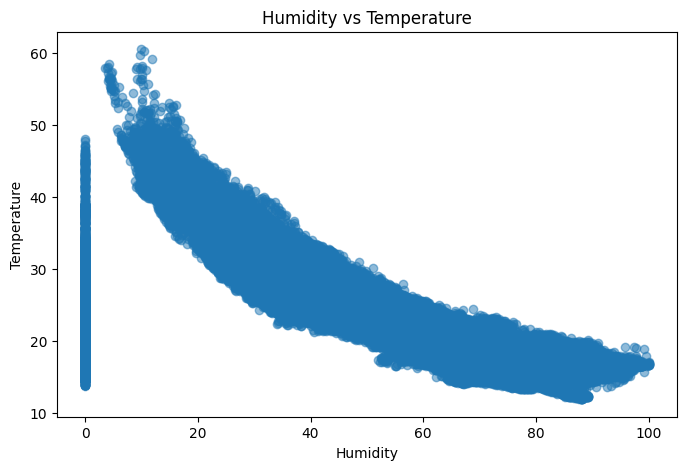

In [12]:
# Scatter plot to observe relationship

plt.figure(figsize=(8,5))
plt.scatter(df["humidity"], df["temperature"], alpha=0.5)
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Humidity vs Temperature")
plt.show()

## Data Preprocessing

In [14]:
# Drop any rows with missing values
df = df.dropna()

# Define features and target
X = df[["humidity"]]
y = df["temperature"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training

In [15]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)



## Evaluation


In [16]:
# Evaluate model performance

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 18.91491445564732
R2 Score: 0.6511489851883403


## Conclusion
- A simple linear regression model was used to predict temperature from humidity.  
- Consider using polynomial regression or time-series models for more complex patterns.
